(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

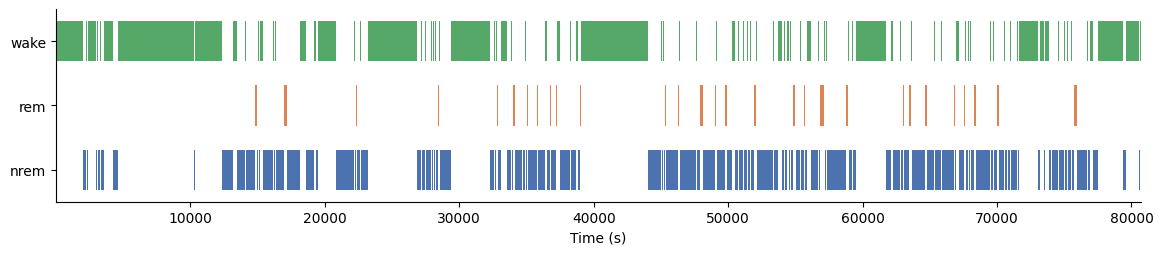

In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = '107b'
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes.npz")
turn_spikes     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "turn_spikes.npz")

plot_intervals(sleep_states, column='state')

In [66]:
ccg_nrem = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'nrem']),
    binsize=20,
    windowsize=4000,
    time_units='ms',
)

ccg_wake = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'wake']),
    binsize=20,
    windowsize=4000,
    time_units='ms',
)

ccg_rem = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'rem']),
    binsize=20,
    windowsize=4000,
    time_units='ms',
)

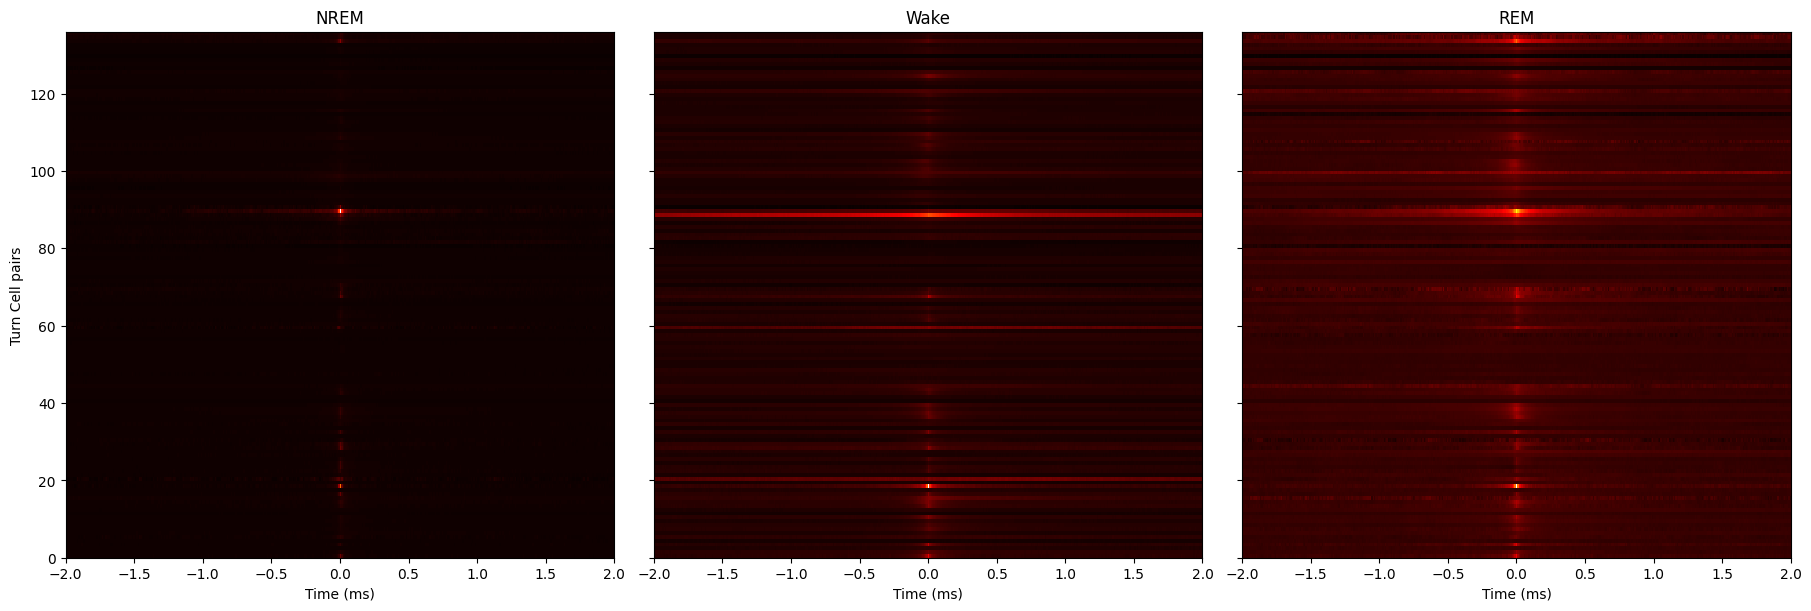

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True, constrained_layout=True)

for i, ccg in enumerate([ccg_nrem, ccg_wake, ccg_rem]):
    data = ccg.to_numpy()
    
    ax[i].imshow(
        data.T,
        aspect='auto',
        origin='lower',
        cmap='hot',
        interpolation='none',
        extent=[-2, 2, 0, 136],
        )
    
    if i == 0:
        ax[i].set_ylabel('Turn Cell pairs')
    ax[i].set_xlabel('Time (ms)')

ax[0].set_title('NREM')
ax[1].set_title('Wake')
ax[2].set_title('REM')
plt.show()